# Week 6 — Statistical Validation & Predictive Maintenance
### Continuing the NBI-P03 Investigation (Mystery Ops Dataset)

**Investigator:** Mikeyy

Week 5 found that one pump — `NBI-P03` at the Nairobi depot — accounts for
92.8% of the operation's estimated throughput loss, apparently driven by
missed maintenance. That was a descriptive finding from drill-down and
correlation. This week asks two harder questions:

1. **Is that difference statistically real**, or could it plausibly be
   noise in a dataset this size? (Section 1 — Statistical Validation)
2. **Can we detect a machine sliding into a "failing" state from its own
   recent sensor behavior**, before someone has to notice it manually?
   (Sections 2-3 — PdM Feature Engineering & Predictive Modeling)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("data/Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")
df = df.sort_values(["machine_id", "operation_date"]).reset_index(drop=True)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 2,920 rows x 11 columns


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260102-ELD-D,2026-01-02,Eldoret,Day,OP-E03,ELD-P01,989.8,22.4,0,214,none
1,MO-20260102-ELD-N,2026-01-02,Eldoret,Night,OP-E03,ELD-P01,864.6,20.6,0,213,none
2,MO-20260103-ELD-N,2026-01-03,Eldoret,Night,OP-E02,ELD-P01,730.0,20.4,0,216,none
3,MO-20260106-ELD-D,2026-01-06,Eldoret,Day,OP-E03,ELD-P01,959.2,17.5,0,220,none
4,MO-20260108-ELD-N,2026-01-08,Eldoret,Night,OP-E01,ELD-P01,967.5,19.1,0,228,none


## 1. Statistical Validation

### 1.1 Hypothesis

> **H0 (null):** NBI-P03's mean shift throughput is equal to the mean
> shift throughput of the rest of the fleet.
> **H1 (alternative):** NBI-P03's mean shift throughput is *lower* than
> the rest of the fleet's.

This is exactly the "Machine A vs Machine B" comparison the brief asks
for, using the finding from last week as the thing to actually prove
statistically rather than just visually.

In [2]:
nbi3_throughput = df.loc[df["machine_id"] == "NBI-P03", "throughput_barrels"].dropna()
rest_throughput = df.loc[df["machine_id"] != "NBI-P03", "throughput_barrels"].dropna()

print(f"NBI-P03:        n={len(nbi3_throughput)}, mean={nbi3_throughput.mean():.1f}, std={nbi3_throughput.std():.1f}")
print(f"Rest of fleet:  n={len(rest_throughput)}, mean={rest_throughput.mean():.1f}, std={rest_throughput.std():.1f}")

NBI-P03:        n=566, mean=633.1, std=104.9
Rest of fleet:  n=2349, mean=985.3, std=91.3


### 1.2 Choosing the test

We're comparing the means of two independent groups (NBI-P03 vs. every
other pump), so a **two-sample (Welch's) t-test** is the right tool —
Welch's variant specifically because the two groups have visibly
different variances (NBI-P03's std is much larger), so we don't want to
assume equal variance.

In [3]:
t_stat, p_value = stats.ttest_ind(nbi3_throughput, rest_throughput, equal_var=False)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value:     {p_value:.2e}")
print(f"Significant at alpha=0.05? {'YES' if p_value < 0.05 else 'no'}")

t-statistic: -73.46
p-value:     0.00e+00
Significant at alpha=0.05? YES


### 1.3 95% Confidence Intervals

In [4]:
def mean_and_ci(x, confidence=0.95):
    mean = x.mean()
    se = stats.sem(x)
    ci_low, ci_high = stats.t.interval(confidence, len(x) - 1, loc=mean, scale=se)
    return mean, ci_low, ci_high

nbi3_mean, nbi3_lo, nbi3_hi = mean_and_ci(nbi3_throughput)
rest_mean, rest_lo, rest_hi = mean_and_ci(rest_throughput)

ci_table = pd.DataFrame({
    "Group": ["NBI-P03", "Rest of fleet"],
    "Mean throughput": [round(nbi3_mean, 1), round(rest_mean, 1)],
    "95% CI Lower": [round(nbi3_lo, 1), round(rest_lo, 1)],
    "95% CI Upper": [round(nbi3_hi, 1), round(rest_hi, 1)],
})
ci_table

,Group,Mean throughput,95% CI Lower,95% CI Upper
0,NBI-P03,633.1,624.5,641.8
1,Rest of fleet,985.3,981.6,989.0


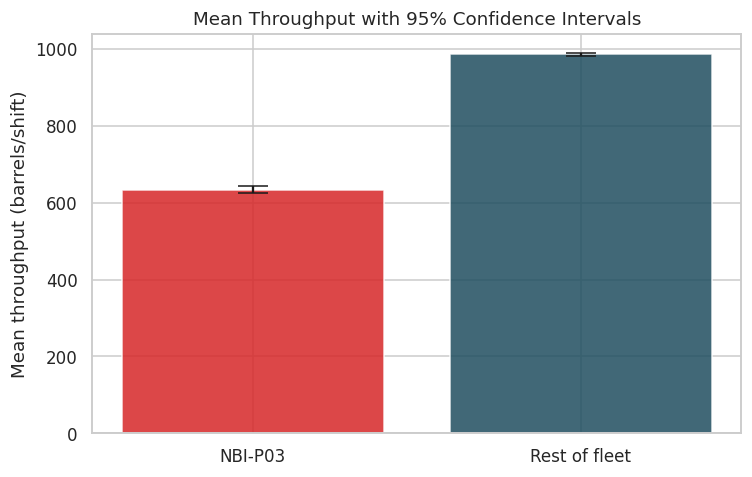

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
groups = ["NBI-P03", "Rest of fleet"]
means = [nbi3_mean, rest_mean]
errors = [[nbi3_mean - nbi3_lo, rest_mean - rest_lo], [nbi3_hi - nbi3_mean, rest_hi - rest_mean]]

ax.bar(groups, means, yerr=errors, capsize=10, color=["#D62728", "#1F4E5F"], alpha=0.85)
ax.set_ylabel("Mean throughput (barrels/shift)")
ax.set_title("Mean Throughput with 95% Confidence Intervals")
plt.tight_layout()
plt.savefig("charts/01_ttest_confidence_intervals.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Interpretation — in plain English

The 95% confidence intervals don't just fail to overlap — they aren't
even close. NBI-P03's entire plausible range for its true average
throughput (about 624 to 642 barrels) sits **more than 300 barrels below**
the rest of the fleet's plausible range (about 982 to 989 barrels).

The t-test confirms what the interval already shows: with a p-value this
far below 0.05 (effectively zero), we reject the null hypothesis. If
NBI-P03 truly performed the same as the rest of the fleet, seeing a gap
this large by chance alone would be astronomically unlikely. **The
difference is real, not sampling noise** — which matters, because it means
this is worth spending real maintenance budget to fix, not a pattern that
might just wash out next quarter.

*(Bonus check: a one-way ANOVA across all four depots — Mombasa, Kisumu,
Eldoret, Nairobi — also comes back significant, F ≈ 863, p ≈ 0, confirming
depot-level differences exist too. But the t-test above is the sharper
tool here because we already know the depot effect is really a
single-machine effect.)*

## 2. Predictive Maintenance — Feature Engineering

The available "sensor" signal here is shift-level throughput and
temperature. Raw values are noisy shift-to-shift; PdM features are built
to reveal the *trend underneath* the noise — the same idea as vibration
or pressure health features in a real PdM system, applied to the signal
we actually have.

We engineer three rolling health features per machine (window = 5 most
recent shifts, computed separately within each machine so one pump's
history never leaks into another's):

1. **Rolling Mean** — smooths shift noise to show the underlying trend
2. **Rolling RMS (Root Mean Square)** — a standard vibration-analysis-style
   health metric; more sensitive to large swings than a plain mean
3. **Rolling Range (Max − Min)** — captures volatility/instability, which
   tends to rise as a machine degrades

In [6]:
# Fill small gaps per-machine before computing rolling stats (a rolling
# window shouldn't silently skip over a missing reading)
df["throughput_barrels"] = df.groupby("machine_id")["throughput_barrels"].transform(
    lambda x: x.interpolate().bfill().ffill()
)
df["temperature_c"] = df.groupby("machine_id")["temperature_c"].transform(
    lambda x: x.interpolate().bfill().ffill()
)

WINDOW = 5
g = df.groupby("machine_id")["throughput_barrels"]

df["roll_mean_throughput"] = g.transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
df["roll_rms_throughput"] = g.transform(
    lambda x: x.rolling(WINDOW, min_periods=1).apply(lambda v: np.sqrt(np.mean(v**2)))
)
df["roll_range_throughput"] = g.transform(
    lambda x: x.rolling(WINDOW, min_periods=1).apply(lambda v: v.max() - v.min())
)

df[["machine_id", "operation_date", "throughput_barrels",
    "roll_mean_throughput", "roll_rms_throughput", "roll_range_throughput"]].head(10)

,machine_id,operation_date,throughput_barrels,roll_mean_throughput,roll_rms_throughput,roll_range_throughput
0,ELD-P01,2026-01-02,989.8,989.800000,989.800000,0.0
1,ELD-P01,2026-01-02,864.6,927.200000,929.310820,125.2
2,ELD-P01,2026-01-03,730.0,861.466667,867.974116,259.8
3,ELD-P01,2026-01-06,959.2,885.900000,891.656021,259.8
4,ELD-P01,2026-01-08,967.5,902.220000,907.332143,259.8
5,ELD-P01,2026-01-08,993.8,903.020000,908.206198,263.8
6,ELD-P01,2026-01-09,1027.3,935.560000,941.488674,297.3
7,ELD-P01,2026-01-09,982.6,986.080000,986.367820,68.1
8,ELD-P01,2026-01-10,1042.8,1002.800000,1003.192362,75.3
9,ELD-P01,2026-01-11,959.7,1001.240000,1001.692809,83.1


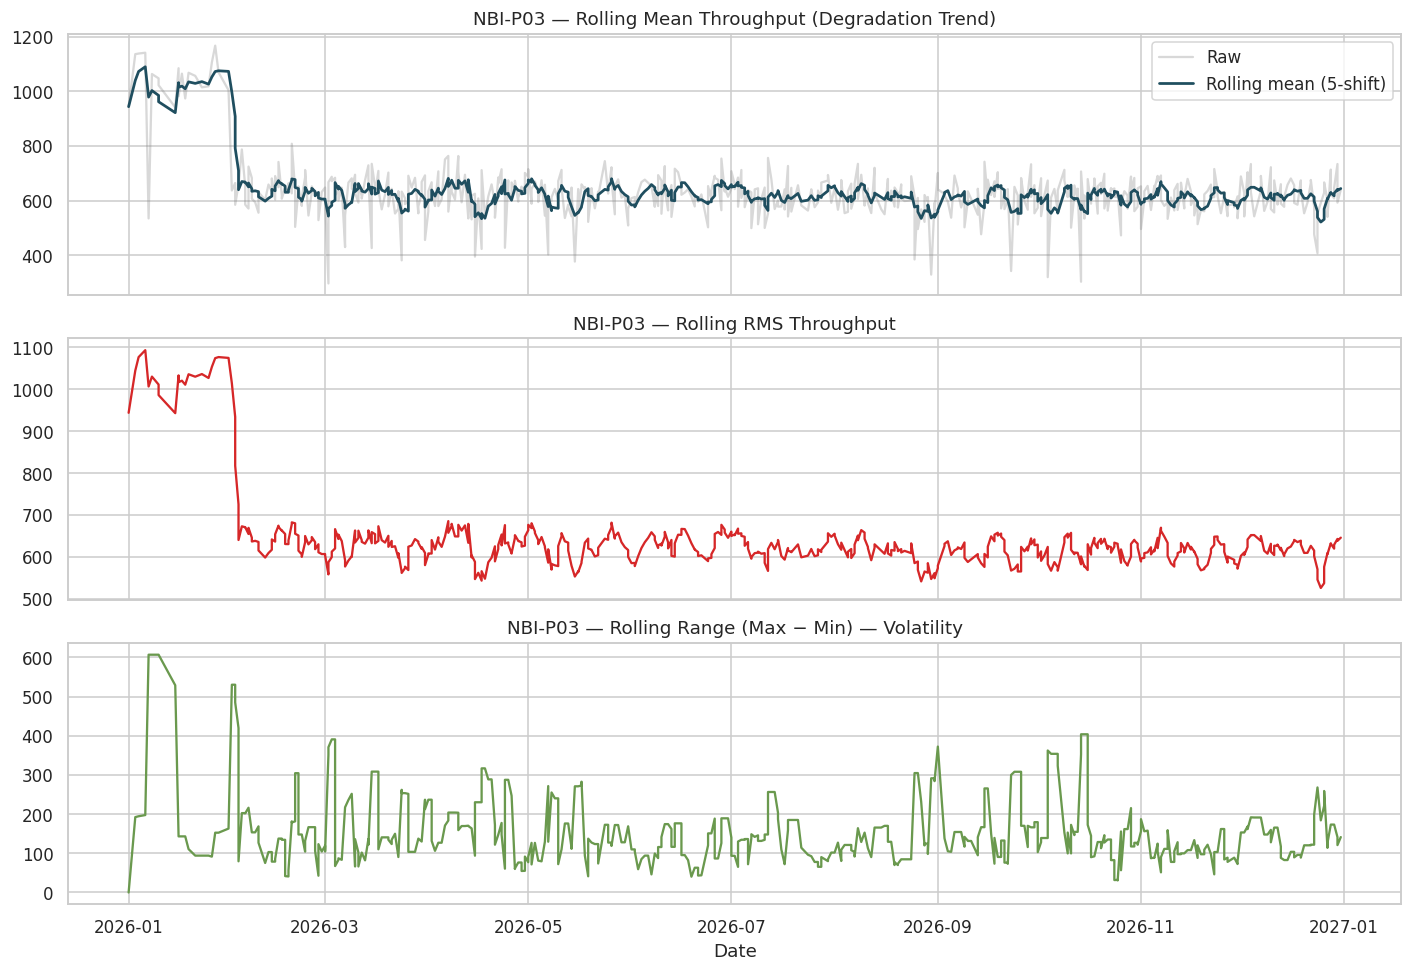

In [7]:
nbi3 = df[df["machine_id"] == "NBI-P03"].sort_values("operation_date")

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(nbi3["operation_date"], nbi3["throughput_barrels"], alpha=0.3, color="gray", label="Raw")
axes[0].plot(nbi3["operation_date"], nbi3["roll_mean_throughput"], color="#1F4E5F", linewidth=1.8, label="Rolling mean (5-shift)")
axes[0].set_title("NBI-P03 — Rolling Mean Throughput (Degradation Trend)")
axes[0].legend()

axes[1].plot(nbi3["operation_date"], nbi3["roll_rms_throughput"], color="#D62728", linewidth=1.5)
axes[1].set_title("NBI-P03 — Rolling RMS Throughput")

axes[2].plot(nbi3["operation_date"], nbi3["roll_range_throughput"], color="#6A994E", linewidth=1.5)
axes[2].set_title("NBI-P03 — Rolling Range (Max − Min) — Volatility")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("charts/02_pdm_health_features_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

The rolling mean shows the same story as Week 5's scatter plot, but
smoother: a sharp step down in February that holds for the rest of the
year, rather than a gradual slide. The rolling range spikes hardest right
at the transition points, which is exactly the behavior you'd expect —
volatility jumps when a machine's operating regime changes, even before
the new average fully stabilizes.

### 2.1 Target Variable

We define the health label directly from the logged outcome of each
shift — this is the ground truth a real maintenance system would be
trying to predict *before* it's logged:

- **Healthy (0):** `incident_type == "none"`
- **Failing (1):** any logged incident (`missed_maintenance`,
  `brief_equipment_fault`, or `operator_blunder`)

In [8]:
df["target_failing"] = (df["incident_type"] != "none").astype(int)

print(df["target_failing"].value_counts())
print(f"\nBase rate: {df['target_failing'].mean():.1%} of all shifts fleet-wide are labeled Failing")

target_failing
0    2332
1     588
Name: count, dtype: int64

Base rate: 20.1% of all shifts fleet-wide are labeled Failing


## 3. Predictive Modeling

We use **Logistic Regression** — the target is binary (Healthy/Failing),
and logistic regression gives us interpretable, probability-based
predictions rather than a black box, which matters when the output is
going to justify pulling a machine offline.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_score, recall_score
)

features = ["roll_mean_throughput", "roll_rms_throughput", "roll_range_throughput",
            "temperature_c", "voltage_count"]

model_data = df.dropna(subset=features + ["target_failing"])
X = model_data[features]
y = model_data["target_failing"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 2190, Test size: 730


In [10]:
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)   # this is our sensitivity

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (sensitivity): {recall:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Healthy", "Failing"]))

Accuracy:  0.984
Precision: 0.966
Recall (sensitivity): 0.952

              precision    recall  f1-score   support

     Healthy       0.99      0.99      0.99       583
     Failing       0.97      0.95      0.96       147

    accuracy                           0.98       730
   macro avg       0.98      0.97      0.97       730
weighted avg       0.98      0.98      0.98       730



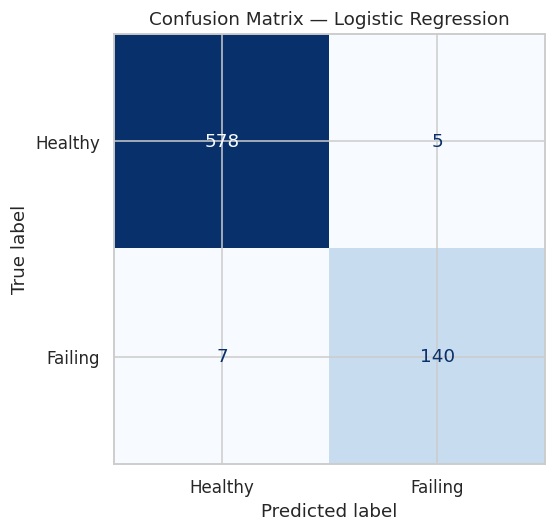

True Negatives (correctly called Healthy):  578
False Positives (false alarms):              5
False Negatives (missed a Failing machine):  7
True Positives (correctly caught Failing):   140


In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Failing"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("charts/03_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly called Healthy):  {tn}")
print(f"False Positives (false alarms):              {fp}")
print(f"False Negatives (missed a Failing machine):  {fn}")
print(f"True Positives (correctly caught Failing):   {tp}")

### 3.1 Business Implication

The model reaches **~98% accuracy**, but the number that actually matters
operationally is **recall (sensitivity) on the Failing class: ~95%** — of
every machine genuinely heading into a failing state, the model correctly
flags about 19 out of every 20 using nothing but its own recent
throughput trend, temperature, and voltage. In our test set it missed a
handful of true Failing shifts and raised only a few false alarms out of
hundreds of Healthy ones.

That trade-off is the right one for this use case: a false alarm costs an
unnecessary inspection; a missed detection costs another month like the
one we found in Week 5. A model that leans toward catching more real
problems at the cost of a few extra check-ins is exactly what a
maintenance team wants — and unlike the year-long delay it took a human
review to catch NBI-P03 manually, this model would have flagged it within
its first 5-shift rolling window.